# LCLS Gun Fieldmap

This is an openPMD-beamphysics fieldmap for the center of the LCLS RF Gun

In [1]:
from pmd_beamphysics import FieldMesh

import numpy as np
import os

c_light = 299792458.

# Nicer plotting
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

In [2]:
H5FILE = 'lcls_gun_fieldmesh.h5'

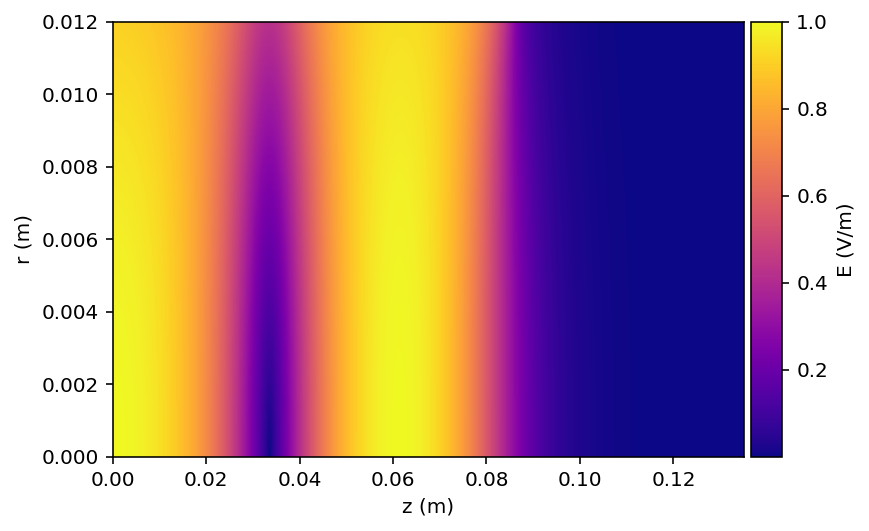

In [3]:
FM = FieldMesh(H5FILE)
FM.plot()

In [4]:
FM.attrs

{'eleAnchorPt': 'beginning',
 'gridGeometry': 'cylindrical',
 'axisLabels': array(['r', 'theta', 'z'], dtype='<U5'),
 'gridLowerBound': array([0, 1, 0]),
 'gridOriginOffset': array([0., 0., 0.]),
 'gridSpacing': array([0.00025, 0.     , 0.00025]),
 'gridSize': array([ 49,   1, 541]),
 'harmonic': 1,
 'fundamentalFrequency': 2855998506.158,
 'RFphase': 0,
 'fieldScale': 1.0}

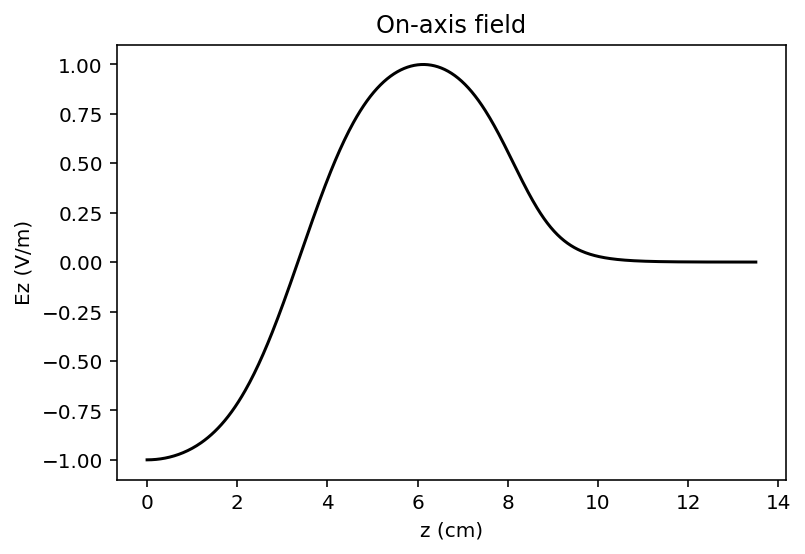

In [5]:
# On-axis field
z0 = FM.coord_vec('z')
Ez0 = np.real(FM.Ez[0,0,:])
plt.title('On-axis field')
plt.xlabel('z (cm)')
plt.ylabel('Ez (V/m)')
plt.plot(z0*100, Ez0, color='black')

# Autophase and Scale

In [6]:
from pmd_beamphysics.fields.analysis import autophase_and_scale_field

In [7]:
# Get scale and phase factors to accelerate to 6 MeV
phase_deg2, scale2 = autophase_and_scale_field(FM, 6e6, pz0=0, verbose=True)
phase_deg2, scale2

v=c voltage: 0.04829891544701423 V, phase: -37.86393304246883 deg
    Pass 1 delta energy: 6000000.286369135 at phase  304.9796362566863 deg
    Pass 2 delta energy: 5999999.999982449 at phase  305.1462086323847 deg


(305.1462086323847, 125274241.17820522)

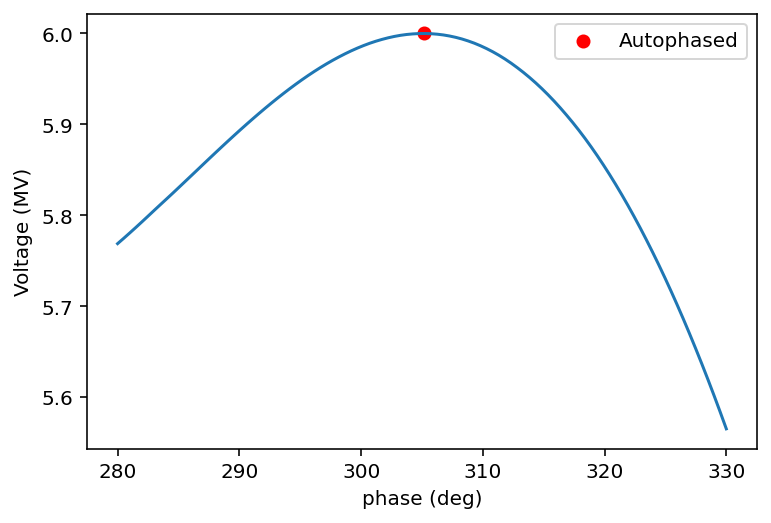

In [8]:
# Use debug mode to visualize. This returns the phasing function
ps_f = autophase_and_scale_field(FM, 6e6, pz0=0, debug=True)
ps_f(phase_deg2, scale2)

plist = np.linspace(280, 330, 100)
denergy = np.array([ps_f(p, scale2) for p in plist])

plt.plot(plist, denergy/1e6)
plt.scatter(phase_deg2, ps_f(phase_deg2, scale2)/1e6, color='red', label='Autophased')
plt.xlabel('phase (deg)')
plt.ylabel('Voltage (MV)')
plt.legend()

# Verify the oscillation

Check that the B-field off-axis oscillates correctly

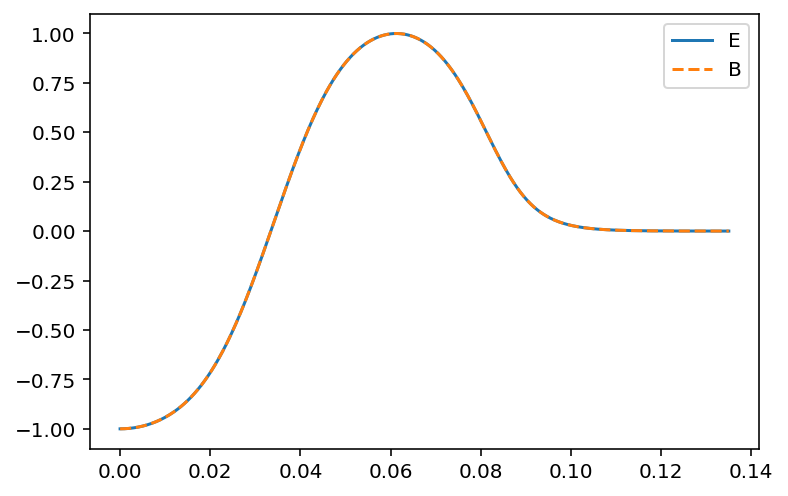

In [9]:
dr = FM.dr
omega = FM.frequency*2*np.pi

z0 = FM.coord_vec('z')
Ez0 = np.real(FM.Ez[0,0,:])
B1 = -np.imag(FM.Btheta[1,0,:])

plt.plot(z0, Ez0, label='E')
plt.plot(z0, B1*2/dr *c_light**2/omega, '--', label='B')
plt.legend()